2. CUSTOMER ANALYSIS

1. BUSINESS UNDERSTANDING

Perusahaan ingin memahami karakteristik pelanggan untuk mengetahui:

- Seberapa aktif pelanggan melakukan transaksi.
- Segment pelanggan yang memberikan kontribusi terbesar.
- Pelanggan dengan nilai transaksi tertinggi.
- Pola pembelian pelanggan.

In [ ]:
2. DATA UNDERSTANDING

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"D:\PROJECT\Superstore Sales Dataset\Dataset\Superstore Sales Dataset.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.shape

(9800, 18)

-> Data set memiliki 9800 data dengan 18 kolom, dengan tipe data yg berbeda terutama untuk kolom Postal Code dan Sales memiliki tipe data float64, yang lain berupa object.

3. DATA PREPARATION & DATA CLEANING

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
df.duplicated().sum()

0

-> Karena pada sebelumnya sudah di cek untuk data set terkait persiapan data dan penyesuaian data pada bagian 1 yaitu Sales Performance Analysis, pada tahap ini karena tidak ada nilai yang kembar, 
hanya kolom postal saja yang memiliki beberapa nilai nol, dan karena pada pengujian kali ini kolom postal code tidak dibutuhkan maka pada analisis kali ini kolom postal code di biarkan ada. 

4. Customer Overview

In [9]:
total_pelanggan = df["Customer ID"].nunique()
total_transaksi = df["Order ID"].nunique()
total_penjualan = df["Sales"].sum()
rata_transaksi_pelanggan = total_transaksi/total_pelanggan
rata_penjualan_pelanggan = total_penjualan/total_pelanggan

print(f"Total Pelanggan                 : {total_pelanggan}")
print(f"Rata Rata Transaksi Pelanggan   : {rata_transaksi_pelanggan:,.0f}")
print(f"Rata Rata Penjualan pelanggan   : ${rata_penjualan_pelanggan:,.2f}")

Total Pelanggan                 : 793
Rata Rata Transaksi Pelanggan   : 6
Rata Rata Penjualan pelanggan   : $2,851.87


-> diatas menjelaskan bahwa pelanggan berjumlah 793, dengan rata rata melakukan pembelian berulang sekitar 6 kali, dan rata rata customer menghabiskan uang sebesar $2,851.87 pada toko.

In [10]:
segmentorder = (
    df.groupby(["Segment"]) ['Order ID']
    .nunique()
    .reset_index()
)

segmentpenjualan = (
    df.groupby("Segment") ['Sales']
    .sum()
    .reset_index()
)

## Pembuatan grup baru untuk yang pertama bernama segment order yang memiliki arti bahwa grup tersebut gabungan antara kolom Segment dan Order ID
## Pembuatan grup baru yang kedua bernama segment perbulan yang memiliki arti bahwa grup tersebut berisi kolom Segment dan Sales

In [11]:
segmentorder.head(10)

,Segment,Order ID
0,Consumer,2537
1,Corporate,1491
2,Home Office,894


Menampilkan grup Segment dan Order ID, untuk grup yang dibuat adalah grup dimana perhitungan total jumlah per segment dengan total dari Order ID,
dilihat hasilnya bahwa segment Consumer merupakan segment terbanyak dan Home Office merupakan segment terkecil, dari hasil diatas dapat disimpulkan bahwa
toko lebih cenderung dan cocok untuk segment consumer.

In [12]:
segmentpenjualan.head(10)

,Segment,Sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


In [13]:
segmentpenjualan_display = segmentpenjualan.copy()

segmentpenjualan_display["Sales"] = segmentpenjualan_display["Sales"].map('${:,.2f}'.format)

segmentpenjualan_display

,Segment,Sales
0,Consumer,"$1,148,060.53"
1,Corporate,"$688,494.07"
2,Home Office,"$424,982.18"


Menampilkan grup segment dan Sales, grup yang dibuat bertujuan untuk meihat segment mana yang memiliki jumlah sales terbesar,
dikarenakan sales memiliki tipe data float64 sehingga data yang ditampilkan menggunakan notasi ilmiah sehingga kita kana mengubah
menjadi data tipe data object agar bisa terlihat lebih rapih dan mudah dibaca.

5. Customer Contribution

In [14]:
segmentpenjualan["Contribution (%)"] = (
    segmentpenjualan["Sales"] /
    segmentpenjualan["Sales"].sum() * 100
)

segmentpenjualan.head()

,Segment,Sales,Contribution (%)
0,Consumer,1.148061e+06,50.764619
1,Corporate,6.884941e+05,30.443638
2,Home Office,4.249822e+05,18.791743


dari data diatas bahwa kontribusi terbanyak adalah segment Consumer dengan angka kontribusi nya lebih dari setengah nya yaitu 50.7%,
dapat disimpulkan bahwa segment consumer menjadi calon segment untuk strategi pemasaran dan retensi pelanggan untuk mendapatkan costumer baru
atau pemasaran produk baru.

6.  Top 10 Customer Analysis

In [ ]:
customer_sales = (
    df.groupby(["Customer ID", "Customer Name"])["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index(name="Total Sales")
)

customer_orderID = (
    df.groupby(["Customer ID", "Customer Name"])["Order ID"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index(name="Total Order")
)

## membuat 2 grup dikarenakan grup pertama bernama customer_sales, berfungsi untuk melakukan berapa total yang di habiskan customer dalam beberapa kali transaksi
## grup customer_orderID berfungsi untuk menampilkan jumlah transaksi keseluruhan untuk satu customer
## dan kedua grupp langsung di urutkan berdasarkan nilai nya untuk customer_sales dari jumlah Sales, dan customer_orderID dari jumlah Order ID 

customer_summary = pd.merge(
    customer_sales,
    customer_orderID,
    on=["Customer ID", "Customer Name"]
)

## menggabungkan 2 grup menjadi 1 dengan nama customer_summary


,Customer ID,Customer Name,Total Sales,Total Order
0,SM-20320,Sean Miller,25043.050,5
1,TC-20980,Tamara Chand,19052.218,5
2,RB-19360,Raymond Buch,15117.339,6
3,TA-21385,Tom Ashbrook,14595.620,4
4,AB-10105,Adrian Barton,14473.571,10
5,KL-16645,Ken Lonsdale,14175.229,12
6,SC-20095,Sanjit Chand,14142.334,9
7,HL-15040,Hunter Lopez,12873.298,6
8,SE-20110,Sanjit Engle,12209.438,11
9,CC-12370,Christopher Conant,12129.072,5


-> Membuat grup baru dengan nama customer sales dan customer order id, grup ini dibuat bertujuan untuk bisa mengetahui
customer yang memberikan sales terbesar, customer yang selalu mengulangi pembelian di toko, customer yang memiliki loyalitas terbanyak,
dan apakah customer dengan transaksi terbanyak merupakan customer yang selalu mengulangi pembelian di toko

In [ ]:
customer_summary.sort_values(
    by="Total Order",
    ascending=False
).head(10)

# menampilkan 10 customer dengan total order terbanyak

,Customer ID,Customer Name,Total Sales,Total Order
94,EP-13915,Emily Phan,5478.0608,17
253,CK-12205,Chloris Kastensmidt,3154.8550,13
262,PG-18820,Patrick Gardner,3086.9070,13
36,ZC-21910,Zuschuss Carroll,8025.7070,13
57,JE-15745,Joel Eaton,6760.8150,13
354,SH-19975,Sally Hughsby,2465.6595,12
362,BP-11095,Bart Pistole,2442.0440,12
28,PK-19075,Pete Kriz,8646.9340,12
33,KD-16495,Keith Dawkins,8181.2560,12
239,HG-14965,Henry Goldwyn,3247.6420,12


In [ ]:
customer_summary_display = customer_summary.copy()

customer_summary_display["Total Sales"] = customer_summary_display["Total Sales"].map('${:,.2f}'.format)

customer_summary_display.head(10)

# menampilkan 10 customer dengan total transaksi terbesar
# memberikan tampilan agar mudah dibaca dengan menambahkan fungsu terdapat 3 angka dibelakang koma, dan 2 angka dibelakang titik

,Customer ID,Customer Name,Total Sales,Total Order
0,SM-20320,Sean Miller,"$25,043.05",5
1,TC-20980,Tamara Chand,"$19,052.22",5
2,RB-19360,Raymond Buch,"$15,117.34",6
3,TA-21385,Tom Ashbrook,"$14,595.62",4
4,AB-10105,Adrian Barton,"$14,473.57",10
5,KL-16645,Ken Lonsdale,"$14,175.23",12
6,SC-20095,Sanjit Chand,"$14,142.33",9
7,HL-15040,Hunter Lopez,"$12,873.30",6
8,SE-20110,Sanjit Engle,"$12,209.44",11
9,CC-12370,Christopher Conant,"$12,129.07",5


7. Customer Purchase Behavior

In [ ]:
order_customer = (
    df.groupby("Customer ID")["Order ID"]
      .nunique()
)

order_customer.value_counts().sort_index()

# mencari rata rata customer melakukan pembelian di toko berapa kali

Order ID
1      13
2      34
3      55
4     106
5     136
6     112
7     111
8      71
9      70
10     42
11     20
12     18
13      4
17      1
Name: count, dtype: int64

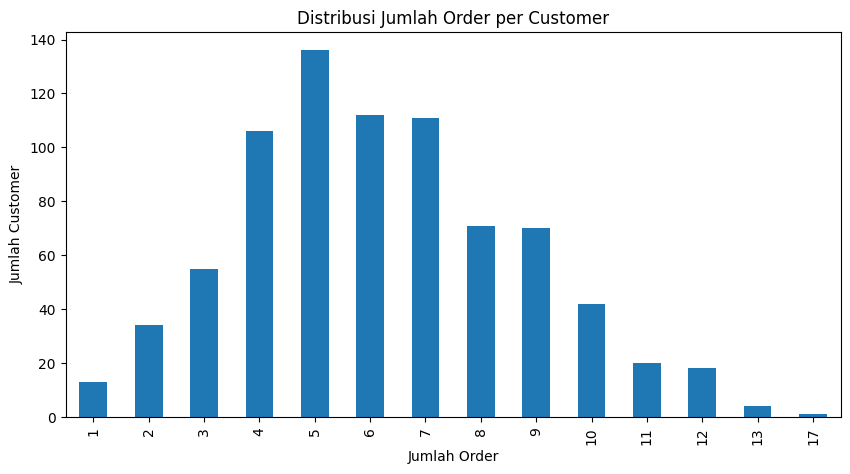

In [32]:
import matplotlib.pyplot as plt

order_customer.value_counts().sort_index().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Distribusi Jumlah Order per Customer")
plt.xlabel("Jumlah Order")
plt.ylabel("Jumlah Customer")
plt.show()

dari hasil pengamatan terkait dengan distribusi jumlah order menunjukkan bahwa sebagian besar pelanggan melakukan 5 hingga 7 transaksi selama periode pengamatan. 
Hal ini mengindikasikan bahwa pelanggan tidak hanya melakukan pembelian satu kali, tetapi cenderung kembali melakukan pembelian berulang (repeat purchase).